In [1]:
!conda install -c conda-forge ipympl

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.

WARNING conda.conda_pypi.main:notify_externally_managed_future(156): 
  Did you know? You can install many PyPI packages with conda
  using the conda-pypi beta. Get started:
    https://docs.conda.io/projects/conda/en/stable/new-features.html



In [2]:
import pickle
import pandas as pd
from utils.utils import *

# Load data
with open('average_tsne.pkl', 'rb') as f:
    average = pickle.load(f)

with open('individual_tsne.pkl', 'rb') as f:
    individual = pickle.load(f)


In [3]:
def plot_projection(X, labels, color='human', figsize=(10, 10), show_text=False):
    """2D scatter projection with external legend."""
    if color == 'human':
        get_color = get_color_human
        get_label = get_label_human
    elif color == 'yeast':
        get_color = get_color_yeast
        get_label = get_label_yeast
    else:
        raise ValueError(f"Unknown color: {color}")

    plt.figure(figsize=figsize)

    for i, label in enumerate(labels):
        plt.scatter(X[i, 0], X[i, 1], color=get_color(label), s=100)
        if show_text:
            plt.text(X[i, 0], X[i, 1], label, color=get_color(label))

    handles = make_legend_handles(labels, get_label, get_color)

    plt.legend(
        handles=handles,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        markerscale=1.5,
        fontsize=12
    )

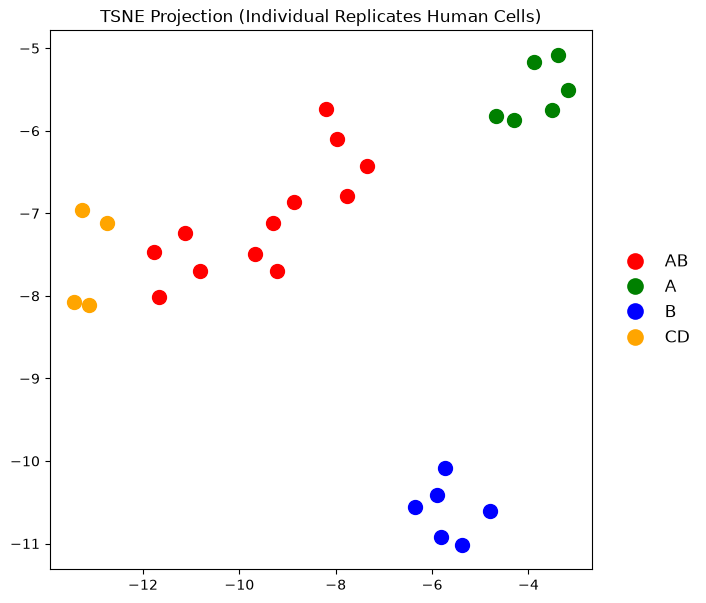

In [4]:
plot_projection(average['y'],average['labels'], figsize=(7,7))
plt.title("TSNE Projection (Individual Replicates Human Cells)")
plt.show()

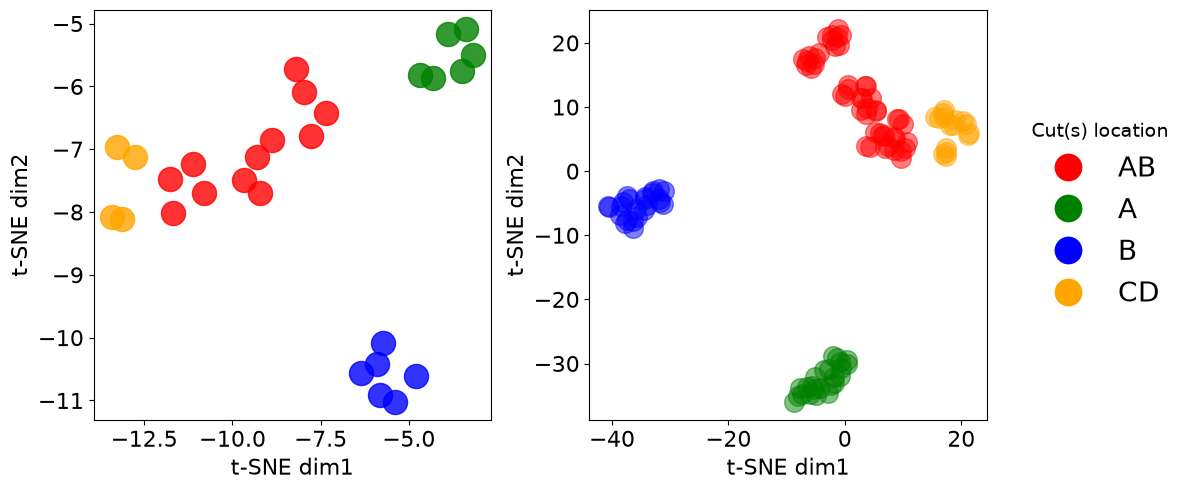

In [5]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.tick_params(axis='both', which='major', labelsize=16)
ax2.tick_params(axis='both', which='major', labelsize=16)

# Plot 1
ax1.set_xlabel('t-SNE dim1',fontsize=16)
ax1.set_ylabel('t-SNE dim2',fontsize=16)

# Plot 2
ax2.set_xlabel('t-SNE dim1',fontsize=16)
ax2.set_ylabel('t-SNE dim2',fontsize=16)

# Get legend handles from one plot (they're the same)
handles = make_legend_handles(average['labels'], get_label_human, get_color_human)

# Plot on both axes
for i, label in enumerate(average['labels']):
    ax1.scatter(average['y'][i, 0], average['y'][i, 1], color=get_color_human(label), s=300, alpha=0.8)

for i, label in enumerate(individual['labels']):
    ax2.scatter(individual['y'][i, 0], individual['y'][i, 1], color=get_color_human(label), s=200, alpha=0.5)


# Adjust layout to make room for the legend
plt.subplots_adjust(bottom=0.2, wspace=0.3)

# Create one big legend at the right
plt.legend(
    handles=handles,
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    frameon=False,
    ncol=1,
    fontsize=20,
    markerscale=2.5,
    title="Cut(s) location",  # ✅ Add this line
    title_fontsize=14
)

# Show the plot
plt.tight_layout()
#plt.show()
plt.savefig('t-SNE projections.pdf', dpi=300, bbox_inches='tight', facecolor='white')

In [16]:
#%matplotlib ipympl
from InDelsTopo import Filtration
import matplotlib.pyplot as plt

# Input: words and associated weights
sequences = ['ATG', 'TATG', 'AT^2G', 'T^2G', 'AG', 
             'A^2G', 'ATAG', 'TG', 'TAG', 'G']
weights = [0.1, 0.2, 0.2, 0.3, 0.3,
           0.4, 0.5, 0.6, 0.7, 1.0]
# Create a Filtration object
K = Filtration()

# Compute d-skeleton of the insertion complex
K.compute_d_skeleton(sequences, weights)

print('\n', K)
print("\n3-blocks:", K[3])

# Visualize the complex graph
#K.get_graph()

# Compute and plot Euler characteristic curve
# euler_curve = K.get_euler_curve()
# plt.figure(figsize=(8,6))
# plt.plot(euler_curve[0], euler_curve[1],linewidth=5)
# plt.xticks(fontsize=24)
# plt.yticks(fontsize=24)
# #plt.show()
# plt.savefig('Euler_characteristic_output.pdf', dpi=300, bbox_inches='tight', facecolor='white')

# # Compute persistent homology barcodes
# persistent_homology = K.get_persistent_homology_barcodes()
# print('\nPersistent Barcodes:', persistent_homology)
# plt.close()

Product symbol set to (concatenation)

 Filtration of Insertion Chain Complexes: 
alphabet: Alphabet with letters: ['A', 'G', 'T'].
heights in: [0.100000000000000,1.00000000000000].
dimension: 3.
vertices: 10.
blocks: 37.

3-blocks: {(1,T)(1,A)(1,T)G: 1.00000000000000, (1,A)(1,T)(1,A)G: 1.00000000000000}


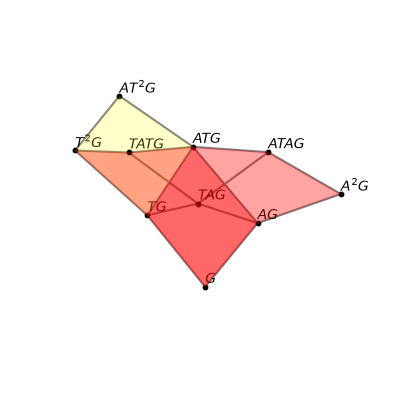

In [42]:
#%matplotlib ipympl
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=6.4, azim=-44.4)  # Adjust these values
K.get_graph(ax=ax)
plt.tight_layout()
plt.savefig('InsertionComplex_output.pdf', dpi=300, bbox_inches='tight', pad_inches=1)

In [34]:
# Get current view angles
elev = ax.elev
azim = ax.azim

print(f"Current view: elev={elev:.1f}°, azim={azim:.1f}°")

Current view: elev=6.4°, azim=-44.4°
